In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import savgol_filter
from scipy.stats import spearmanr
from scipy.stats import rankdata
import pingouin as pg
import pandas as pd

In [34]:
long_GRBs = """
GRB080723557	58.369	3.072	1.74E+02	55	8	35.571	158/167	28.1 
GRB080804972	24.704	0.256	2.21E+02	13	8	13.585	30/167	73.6 
GRB080816503	64.769	1.28	1.26E+02	23	8	12.896	57/167	77.5 
GRB080817161	60.289	2.048	3.63E+02	18	8	24.122	107/167	41.5 
GRB080825593	20.992	1.216	1.74E+02	29	11	34.897	155/167	28.7 
GRB080906212	2.875	0.005	1.27E+02	23	13	25.469	113/167	39.3 
GRB080916009	62.977	1.28	6.68E+02	28	8	28.163	125/167	35.5 
GRB080925775	31.744	-1.024	1.64E+02	49	10	27.938	124/167	35.8 
GRB081009140	41.345	1.344	2.93E+01	60	9	35.347	157/167	28.3 
GRB081125496	9.28	0.512	1.66E+02	21	8	10.203	45/167	98 
GRB081129161	62.657	-0.128	2.56E+02	26	8	13.57	60/167	73.7 
GRB081221681	29.697	3.328	8.69E+01	45	10	35.122	156/167	28.5 
GRB090102122	26.624	1.536	4.25E+02	11	8	17.386	77/167	57.5 
GRB090131090	35.073	3.072	4.66E+01	43	10	23.897	106/167	41.8 
GRB090328401	61.697	4.352	6.51E+02	8	8	15.142	67/167	66 
GRB090411991	14.336	0.768	1.72E+02	45	8	18.733	83/167	53.4 
GRB090424592	14.144	0.512	1.60E+02	4	8	31.979	142/167	31.3 
GRB090425377	75.393	3.584	4.35E+01	12	9	11.774	52/167	84.9 
GRB090528516	79.041	4.352	2.31E+02	4	8	5.264	23/167	190 
GRB090626189	48.897	1.536	1.87E+02	25	9	34.224	152/167	29.2  
GRB090718762	23.744	3.392	1.62E+02	8	9	30.407	135/167	32.9 
GRB090829672	67.585	10.24	4.70E+02	15	8	13.795	61/167	72.5 
GRB090831317	39.424	0	2.56E+02	49	11	34.897	155/167	28.7 
GRB200716957	5.312	0.128	4.70E+02	8	10	306.032	136/167	3.3 
GRB240619155	36.126	-1	3.24E+02	3	11	25.02	111/167	40	0.3965				
GRB220527387	10.496	-5	1.22E+02	3	26	8.406	37/167	119	0.857
GRB211023546	79.106	5.041	8.63E+01	4	14	15.142	67/167	66	0.39
GRB200613229	478.026	-6.5	-	159	8	35.571	158/167	28.1	1.22
GRB180703876	20.736	-5	-	4	16	33.775	150/167	29.6	0.6678
GRB160625945	453.385	35	4.71E+02	155	12	34.673	154/167	28.8	1.406
GRB160623209	107.776	-1.28	-	4	8	15.366	68/167	65.1	0.367
GRB150514774	10.813	-5.8	-	2	33	29.958	133/167	33.4	0.807
GRB140808038	4.477	3	-	0	18	29.958	133/167	33.4	3.29"""

# Outliers in the sample: 
#GRB081224887	16.448	0.736	4.09E+02	13	10	4.365	19/167	229.1
#GRB200716957	5.312	0.128	4.70E+02	8	10	306.032	136/167	3.3

In [35]:
short_GRBs = """GRB080723913	0.192	-0.064		4	11	120.016	53/167	8.3
GRB081216531	1.664	-0.192		5	4	49.607	22/200	20.2
GRB090227772	1.28	-0.016		10	9	342.038	152/167	2.9"""

In [36]:
redshift_GRBs = '''GRB220527387	10.496	-5	1.22E+02	3	26	8.406	37/167	119	0.857
GRB211023546	79.106	5.041	8.63E+01	4	14	15.142	67/167	66	0.39
GRB200613229	478.026	-6.5	-	159	8	35.571	158/167	28.1	1.22
GRB180703876	20.736	-5	-	4	16	33.775	150/167	29.6	0.6678
GRB160625945	453.385	35	4.71E+02	155	12	34.673	154/167	28.8	1.406
GRB160623209	107.776	-1.28	-	4	8	15.366	68/167	65.1	0.367
GRB150514774	10.813	-5.8	-	2	33	29.958	133/167	33.4	0.807
GRB140808038	4.477	3	-	0	18	29.958	133/167	33.4	3.29
GRB240619155	36.126	-1	3.24E+02	3	11	25.02	111/167	40	0.3965'''

Parse the GRB catalog (copy and pasted from google sheets file)

In [37]:
GRB_catalog = {}
preburst_buffer = 1

for line in long_GRBs.strip().splitlines():
    columns = line.split('\t')
    GRB_catalog[columns[0]] = {
        'T90':          float(columns[1]),
        'T90 start':    float(columns[2]),
        'cluster_size': int(columns[4]),
        'QTMVT':        float(columns[8]),
        'redshift':     np.nan,
        'type':         'long'}

for line in short_GRBs.strip().splitlines():
    columns = line.split('\t')
    GRB_catalog[columns[0]] = {'T90': float(columns[1]), 'T90 start': float(columns[2]), 'cluster_size': int(columns[4]), 'QTMVT': float(columns[8]), 'type':'short'}

for line in redshift_GRBs.strip().splitlines():
    columns = line.split('\t')
    GRB_catalog[columns[0]] = {
        'T90':          float(columns[1]),
        'T90 start':    float(columns[2]),
        'cluster_size': int(columns[4]),
        'QTMVT':        float(columns[8]),
        'redshift':     float(columns[9]),
        'type':         'long'}

Define the pulses from Bhat paper: https://arxiv.org/pdf/1109.4064
With theory credit to https://arxiv.org/pdf/1205.0055

Loop through each GRB and find the rise times of each peak

Rise time is measured from the local minimum preceding each peak, to the tip of the peak. Minimum rise time is taken across all the detected pulses per GRB. 

In [38]:
results = []
minimum_cluster_size = 2
for GRB_name, parameters in GRB_catalog.items():
    signal = np.load(f'{GRB_name}_signal.npy')
    time = np.load(f'{GRB_name}_time.npy')
    Tbin = float(np.load(f'{GRB_name}_Tbin.npy')[0])
    
    T5 = parameters['T90 start']
    T95 = T5+parameters['T90']
    preburst_start = time[1]
    preburst_end = 0-preburst_buffer 
    preburst_mask = (time >= preburst_start) & (time < preburst_end)
    burst_mask = (time>=T5)&(time<=T95)
    ### Finding the Peaks ###
    
    # Calculate window saize for the smoothing filter 
    if parameters['type'] == 'short':
        smoothed_section = parameters['T90']*0.1 # Window ~100ms, this is around the shorter pulse times in short GRBs
    else:
        smoothed_section = 1 # 1 second windows for the long GRBs
    window = max(3, int(smoothed_section/Tbin) )
    # Set any negative values in the background subtracted signal to 0
    signal_positive = np.clip(signal,0,None) 
    smoothed_signal = savgol_filter(signal_positive, window, 2) # 2 for second order polynamial to each window
    # Extract signal and time within the burst window only 
    smoothed_burst = smoothed_signal[burst_mask]
    smoothed_burst_time = time[burst_mask] 
    # Calculate peak threshold from mean and SD
    mean_background = np.mean(signal[preburst_mask])
    standard_deviation_background = np.std(signal[preburst_mask])
    peak_threshold = mean_background+2 * standard_deviation_background ### Maybeee change to 2 to add less false positives if coming up with too many 
    # peaks must be separated by at least 5% of burst duration, and never less than 0.1 seconds
    minimum_peak_separation = int(max(0.1/Tbin, parameters['T90']*0.05/ Tbin) )
    # Make al list of all the peak information (smoothed burst data, threshold, distance between peaks)  
    peaks = find_peaks(smoothed_burst, height=peak_threshold, distance= minimum_peak_separation)[0] # Just get the first element of list 
    N_pulses = len(peaks)
    ### Finding the Rise Times ###
    rise_times = [] # Per GRB
    
    for p in peaks: 
        # Define a search window start 2 seocnds before the peak, rise time = time from that trough to the peak. max() so it doesn't go before beginning of burst
        peak_finder_start = max(0, p - int(2/Tbin)) # 2 seconds worth of bins to the left of the peak, in # of bins
        pre_peak = smoothed_burst[peak_finder_start : p] # slices the smoothed burst array to give us the section between the start of the finder and the peak 
        # if there are no bins between the finder start and the peak, skip over that part
        if len(pre_peak) ==0:
            continue
        trough_location = peak_finder_start + np.argmin(pre_peak) # find the index where where the minimum is within the 2 second prepeak window
        rise_time = smoothed_burst_time[p] - smoothed_burst_time[trough_location] # Time difference between the peak and the trough in seconds
        if rise_time > 0: # does NOT use maclachlan's argument that it needs to be larger than Tbin
            rise_times.append(rise_time) 
    # Find the minimum rise time
    minimum_rise_time = np.min(rise_times) if rise_times else np.nan
    results.append({'GRB': GRB_name, 
                    'type': parameters['type'], 
                    'T90': parameters['T90'], 
                    'QTMVT': parameters['QTMVT'], 
                    'N_pulses': N_pulses, 
                    'minimum_rise_time': minimum_rise_time, 
                    'redshift': parameters.get('redshift', np.nan),  
                    'QTMVT_rfc': parameters['QTMVT']/(1+parameters.get('redshift', np.nan)) if np.isfinite(parameters.get('redshift', np.nan)) else np.nan,
                    'minimum_rise_time_rfc': minimum_rise_time/(1+parameters.get('redshift', np.nan)) if np.isfinite(parameters.get('redshift', np.nan)) and np.isfinite(minimum_rise_time) else np.nan,})
    print(f"{GRB_name}: {parameters['T90']}s | Minimum rise Time: {minimum_rise_time*1000:.1f}ms | Number of Pulses: {N_pulses} | QTMVT: {parameters['QTMVT']:.1f}ms")

GRB080723557: 58.369s | Minimum rise Time: 20.0ms | Number of Pulses: 11 | QTMVT: 28.1ms
GRB080804972: 24.704s | Minimum rise Time: nanms | Number of Pulses: 0 | QTMVT: 73.6ms
GRB080816503: 64.769s | Minimum rise Time: 570.0ms | Number of Pulses: 5 | QTMVT: 77.5ms
GRB080817161: 60.289s | Minimum rise Time: 690.0ms | Number of Pulses: 5 | QTMVT: 41.5ms
GRB080825593: 20.992s | Minimum rise Time: 10.0ms | Number of Pulses: 12 | QTMVT: 28.7ms
GRB080906212: 2.875s | Minimum rise Time: 710.0ms | Number of Pulses: 4 | QTMVT: 39.3ms
GRB080916009: 62.977s | Minimum rise Time: 510.0ms | Number of Pulses: 13 | QTMVT: 35.5ms
GRB080925775: 31.744s | Minimum rise Time: 10.0ms | Number of Pulses: 7 | QTMVT: 35.8ms
GRB081009140: 41.345s | Minimum rise Time: 10.0ms | Number of Pulses: 4 | QTMVT: 28.3ms
GRB081125496: 9.28s | Minimum rise Time: 1790.1ms | Number of Pulses: 3 | QTMVT: 98.0ms
GRB081129161: 62.657s | Minimum rise Time: 710.0ms | Number of Pulses: 1 | QTMVT: 73.7ms
GRB081221681: 29.697s | Mi

Plot Results and do statistical test of correlation 

Long GRBs (N=29): rho = 0.4955,  p = 0.0063
Short GRBs (N=3): rho = 1.0000, p = 0.0000
All GRBs(N=32): rho = 0.5135,  p = 0.0026
MVT vs T90: rho =0.1570, p = 0.4162
Rise time versus T90: rho = 0.1768, p = 0.3588
MVT vs rise time with T90 removed: rho = 0.4812, p = 0.0095


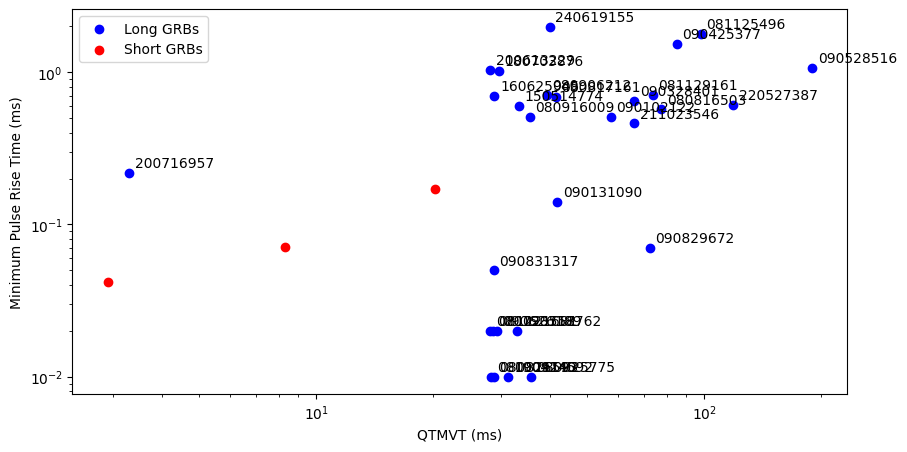

Just a note: I showed the few short GRBs that worked for this Q-transform method, but really this test is best for the long GRBs we currently have.


In [39]:
# Results
long_results = [a for a in results if a['type'] == 'long' and np.isfinite(a['minimum_rise_time']) and GRB_catalog[a['GRB']]['cluster_size'] >= minimum_cluster_size]
short_results = [a for a in results if a['type'] == 'short' and np.isfinite(a['minimum_rise_time'])]
all_results = long_results + short_results

# QTMVT
long_qtmvt = np.array([a['QTMVT'] for a in long_results])
short_qtmvt = np.array([a['QTMVT'] for a in short_results])
all_qtmvt = np.array([a['QTMVT'] for a in all_results])

# Rise times
long_rise  = np.array([a['minimum_rise_time'] for a in long_results])
short_rise = np.array([a['minimum_rise_time'] for a in short_results])
all_rise = np.array([a['minimum_rise_time'] for a in all_results])

# T90
long_t90 = np.array([a['T90'] for a in long_results])

# Spearman test: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html
rho_long, p_long = spearmanr(long_qtmvt, long_rise)
rho_short, p_short = spearmanr(short_qtmvt, short_rise)
rho_all, p_all = spearmanr(all_qtmvt, all_rise)

# Run a spearman test for the correlation between
rho_t90_tau, p_t90_tau = spearmanr(long_qtmvt,long_t90)
rho_t90_rise, p_t90_rise = spearmanr(long_rise, long_t90)

# Partial correlation for long GRBs controlling for T90: https://pingouin-stats.org/generated/pingouin.partial_corr.html
df = pd.DataFrame({'MVT': long_qtmvt, 'rise_time': long_rise, 'T90': long_t90})
T90_exclusion = pg.partial_corr(data=df,x='MVT',y='rise_time',covar='T90',method='spearman')
rho_T90_exclusion = T90_exclusion['r'].values[0]
p_T90_exclusion = T90_exclusion['p_val'].values[0]

print(f"Long GRBs (N={len(long_qtmvt)}): rho = {rho_long:.4f},  p = {p_long:.4f}")
print(f"Short GRBs (N={len(short_qtmvt)}): rho = {rho_short:.4f}, p = {p_short:.4f}")
print(f"All GRBs(N={len(all_qtmvt)}): rho = {rho_all:.4f},  p = {p_all:.4f}")
print(f"MVT vs T90: rho ={rho_t90_tau:.4f}, p = {p_t90_tau:.4f}")
print(f"Rise time versus T90: rho = {rho_t90_rise:.4f}, p = {p_t90_rise:.4f}")
print(f"MVT vs rise time with T90 removed: rho = {rho_T90_exclusion:.4f}, p = {p_T90_exclusion:.4f}")

### Plot ###
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(long_qtmvt,  long_rise,  color='blue', label=f'Long GRBs')
ax.scatter(short_qtmvt, short_rise, color='red',  label=f'Short GRBs')
ax.set_xlabel('QTMVT (ms)')
ax.set_ylabel('Minimum Pulse Rise Time (ms)')
ax.set_xscale('log')
ax.set_yscale('log')
for i, r in enumerate(long_results):
    ax.annotate(r['GRB'][3:], (long_qtmvt[i], long_rise[i]), fontsize=10, xytext=(4,4),textcoords='offset points')
ax.legend()
plt.show()

print("Just a note: I showed the few short GRBs that worked for this Q-transform method, but really this test is best for the long GRBs we currently have.")

In [40]:
# Baht et al.'s pulse counts from https://arxiv.org/pdf/1109.4064
bhat_pulses = {
'GRB080723557': 29,
'GRB080817161': 14,
'GRB080825593': 20,
'GRB080906212': 5,
'GRB080916009': 32,
'GRB080925775': 15,
'GRB081125496': 4,
'GRB081129161': 2,
'GRB081224887': 4,
'GRB090102122': 25,
'GRB090131090': 8,
'GRB090328401': 7,
'GRB090424592': 15,
'GRB090425377': 3,
'GRB090528516': 16,
'GRB090626189': 24,}

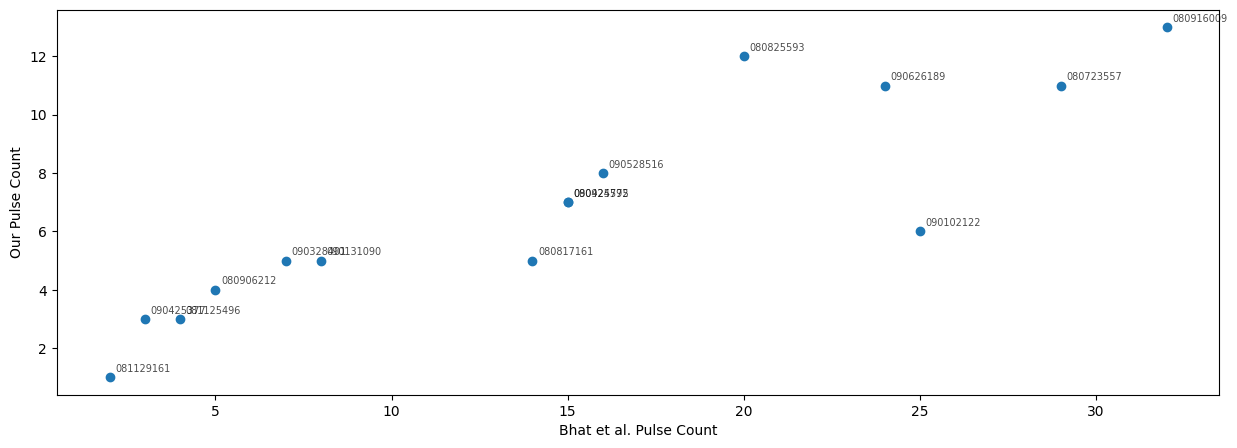

(N=15): rho = 0.9245, p = 0.000001


In [41]:
# See if they match our pulse count results
our_pulses  = []
bhat_counts = []
matches = []

for b in results:
    if b['GRB'] in bhat_pulses:
        our_pulses.append(b['N_pulses'])
        bhat_counts.append(bhat_pulses[b['GRB']])
        matches.append(b['GRB'][3:]) # matches to the GRB number

our_pulses = np.array(our_pulses)
bhat_counts = np.array(bhat_counts)
rho,p = spearmanr(our_pulses,bhat_counts)

fig, ax = plt.subplots(figsize=(15, 5))
ax.scatter(bhat_counts, our_pulses)
for i, name in enumerate(matches):
    ax.annotate(name, (bhat_counts[i], our_pulses[i]), fontsize=7, alpha=0.7, xytext=(4, 4), textcoords='offset points')
ax.set_ylabel('Our Pulse Count')
ax.set_xlabel('Bhat et al. Pulse Count')
plt.show()

print(f"(N={len(our_pulses)}): rho = {rho:.4f}, p = {p:f}")

Copy and pasted table from Bhat et al. 2012 Minimum Rise Times https://content.cld.iop.org/journals/0004-637X/744/2/141/revision1/apj407766t3_mrt.txt

In [42]:
bhat_table_raw = """bn080723557 0.025 NaI  1   96.5       0.0292    0.000368   0.000087     0.000368  0.000087   0.000514   0.00012  
bn080723557 0.025 NaI  2   36.9       1.41      0.731      0.0032       0.785     0.0037     1.06       0.0048   
bn080723557 0.025 NaI  3   11.7       2.36      0.160      0.00076      0.162     0.00079    0.225      0.0011   
bn080723557 0.025 NaI  4    6.22     10.7       0.228      0.0024       0.231     0.0025     0.320      0.0034   
bn080723557 0.025 NaI  5   23.8      11.4       0.340      0.0014       0.347     0.0014     0.479      0.0019   
bn080723557 0.025 NaI  6  102.       12.6       0.896      0.0019       0.943     0.0021     1.28       0.0028   
bn080723557 0.025 NaI  7   45.3      13.9       0.450      0.0014       0.461     0.0015     0.635      0.0020   
bn080723557 0.025 NaI  8   22.5      14.7       0.273      0.0011       0.277     0.0011     0.384      0.0016   
bn080723557 0.025 NaI  9   30.0      15.6       0.504      0.0020       0.517     0.0021     0.712      0.0029   
bn080723557 0.025 NaI 10   19.9      17.1       0.753      0.0047       0.781     0.0051     1.07       0.0069   
bn080723557 0.025 NaI 11   34.3      20.4       0.382      0.0012       0.388     0.0013     0.538      0.0017   
bn080723557 0.025 NaI 12   15.6      21.8       0.361      0.0026       0.367     0.0026     0.508      0.0036   
bn080723557 0.025 NaI 13   57.6      22.0       1.73       0.012        1.87      0.014      2.51       0.017    
bn080723557 0.025 NaI 14   15.1      24.0       0.308      0.0017       0.311     0.0017     0.432      0.0024   
bn080723557 0.025 NaI 15   22.7      40.8       1.09       0.010        1.12      0.011      1.54       0.015    
bn080723557 0.025 NaI 16    4.65     41.7       0.146      0.0021       0.147     0.0021     0.205      0.0030   
bn080723557 0.025 NaI 17   22.1      42.2       0.351      0.0058       0.354     0.0059     0.492      0.0081   
bn080723557 0.025 NaI 18   16.7      42.6       0.341      0.0060       0.344     0.0061     0.478      0.0085   
bn080723557 0.025 NaI 19   19.8      43.4       0.294      0.0031       0.296     0.0032     0.412      0.0044   
bn080723557 0.025 NaI 20   10.3      43.8       0.538      0.029        0.546     0.030      0.757      0.042    
bn080723557 0.025 NaI 21   17.8      45.2       1.35       0.044        1.40      0.047      1.92       0.063    
bn080723557 0.025 NaI 22   63.7      47.5       0.987      0.0045       1.01      0.0048     1.40       0.0065   
bn080723557 0.025 NaI 23   96.3      50.3       2.54       0.016        2.70      0.019      3.66       0.024    
bn080723557 0.025 NaI 24   29.5      54.5       0.349      0.0013       0.352     0.0013     0.489      0.0018   
bn080723557 0.025 NaI 25   15.2      55.0       0.157      0.00061      0.157     0.00061    0.219      0.00085  
bn080723557 0.025 NaI 26   75.6      55.9       0.653      0.0014       0.662     0.0014     0.918      0.0020   
bn080723557 0.025 NaI 27   95.7      56.9       3.03       0.013        3.24      0.015      4.38       0.019    
bn080723557 0.025 NaI 28   11.6      58.0       0.165      0.00081      0.166     0.00081    0.231      0.0011   
bn080723557 0.025 NaI 29   25.1      58.6       0.348      0.0012       0.351     0.0012     0.488      0.0017   
bn080723985 0.050 NaI  1   57.6       0.487     3.36       0.76        39.6      13.        17.7        4.6      
bn080723985 0.050 NaI  2   14.9       4.74      1.10       0.023        1.32      0.033      1.68       0.039    
bn080723985 0.050 NaI  3   68.0       7.81      2.96       0.088        4.36      0.19       5.03       0.19     
bn080723985 0.050 NaI  4   32.1       9.32      0.840      0.012        0.906     0.014      1.22       0.018    
bn080723985 0.050 NaI  5   14.3      10.4       0.524      0.0084       0.547     0.0091     0.747      0.012    
bn080723985 0.050 NaI  6   23.4      13.5       0.587      0.0062       0.615     0.0067     0.839      0.0090   
bn080723985 0.050 NaI  7  216.       15.0       2.36       0.0090       2.80      0.013      3.59       0.015    
bn080723985 0.050 NaI  8   21.3      15.4       0.535      0.0056       0.553     0.0059     0.759      0.0080   
bn080723985 0.050 NaI  9  110.       17.3       1.38       0.0098       1.50      0.012      2.00       0.015    
bn080723985 0.050 NaI 10   11.0      18.3       0.368      0.0057       0.375     0.0059     0.519      0.0081   
bn080723985 0.050 NaI 11   22.1      22.1       3.40       0.32         4.07      0.46       5.20       0.54     
bn080723985 0.050 NaI 12    8.12     23.6       0.422      0.0077       0.431     0.0080     0.595      0.011    
bn080723985 0.050 NaI 13   29.2      25.6       1.66       0.032        1.79      0.037      2.41       0.048    
bn080723985 0.050 NaI 14   45.8      37.7       1.49       0.0099       1.56      0.011      2.13       0.014    
bn080723985 0.050 NaI 15   73.8      40.6       6.02       0.082        7.39      0.12       9.31       0.14     
bn080723985 0.050 NaI 16   17.1      43.0       0.702      0.0078       0.717     0.0081     0.990      0.011    
bn080723985 0.050 NaI 17   32.2      44.7       0.658      0.0071       0.670     0.0073     0.927      0.010    
bn080723985 0.050 NaI 18   59.7      45.7       1.02       0.012        1.05      0.013      1.44       0.018    
bn080817161 0.050 NaI  1   46.4       1.28      3.71       0.19        22.7       2.2       13.5        0.96     
bn080817161 0.050 NaI  2  175.        3.08      2.54       0.0097       3.32      0.017      4.06       0.018    
bn080817161 0.050 NaI  3   94.8       5.56      0.975      0.0042       1.06      0.0049     1.42       0.0063   
bn080817161 0.050 NaI  4  190.        7.63      1.37       0.0094       1.52      0.012      2.01       0.015    
bn080817161 0.050 NaI  5   12.7       9.59      0.622      0.034        0.648     0.037      0.887      0.050    
bn080817161 0.050 NaI  6   11.1      10.2       0.308      0.0068       0.314     0.0071     0.434      0.0097   
bn080817161 0.050 NaI  7   46.1      11.2       0.665      0.013        0.693     0.014      0.947      0.019    
bn080817161 0.050 NaI  8   55.9      12.5       0.817      0.0087       0.858     0.0096     1.17       0.013    
bn080817161 0.050 NaI  9  133.       14.5       1.60       0.023        1.75      0.027      2.34       0.035    
bn080817161 0.050 NaI 10   13.1      15.5       0.351      0.0041       0.358     0.0042     0.495      0.0058   
bn080817161 0.050 NaI 11   10.1      16.9       0.273      0.0031       0.277     0.0032     0.384      0.0044   
bn080817161 0.050 NaI 12  164.       18.2       2.36       0.022        2.66      0.028      3.49       0.035    
bn080817161 0.050 NaI 13  385.       18.6       7.06       0.14        10.9       0.30      12.3        0.29     
bn080817161 0.050 NaI 14   54.2      48.2       3.92       0.030        4.35      0.037      5.77       0.047    
bn080825593 0.020 NaI  1  109.        1.40      0.183      0.0061       0.198     0.0068     0.266      0.0090   
bn080825593 0.020 NaI  2   12.7       1.84      0.315      0.0031       0.341     0.0036     0.457      0.0047   
bn080825593 0.020 NaI  3   41.3       2.09      0.473      0.0050       0.528     0.0062     0.698      0.0078   
bn080825593 0.020 NaI  4   17.2       2.95      0.244      0.0040       0.256     0.0045     0.349      0.0059   
bn080825593 0.020 NaI  5   39.2       3.35      0.456      0.020        0.498     0.024      0.665      0.030    
bn080825593 0.020 NaI  6   33.5       4.05      0.555      0.016        0.613     0.020      0.814      0.025    
bn080825593 0.020 NaI  7   14.5       4.95      0.286      0.0033       0.299     0.0036     0.408      0.0048   
bn080825593 0.020 NaI  8   12.2       5.45      0.318      0.0045       0.334     0.0050     0.455      0.0067   
bn080825593 0.020 NaI  9   63.6       6.11      1.61       0.020        2.09      0.033      2.57       0.036    
bn080825593 0.020 NaI 10   26.4       9.59      0.492      0.0018       0.519     0.0020     0.705      0.0026   
bn080825593 0.020 NaI 11   33.7      11.4       0.689      0.0026       0.737     0.0030     0.995      0.0039   
bn080825593 0.020 NaI 12    7.70     13.8       0.232      0.0040       0.237     0.0042     0.328      0.0057   
bn080825593 0.020 NaI 13    6.35     14.3       0.213      0.0033       0.216     0.0034     0.300      0.0047   
bn080825593 0.020 NaI 14   61.9      15.0       1.13       0.012        1.23      0.014      1.65       0.018    
bn080825593 0.020 NaI 15    4.39     15.9       0.163      0.0023       0.165     0.0024     0.229      0.0033   
bn080825593 0.020 NaI 16   12.8      16.4       0.354      0.0029       0.363     0.0031     0.501      0.0042   
bn080825593 0.020 NaI 17    7.56     17.0       0.0660     0.00028      0.0663    0.00028    0.0923     0.00039  
bn080825593 0.020 NaI 18   33.7      17.7       0.714      0.0028       0.751     0.0031     1.02       0.0041   
bn080825593 0.020 NaI 19    3.58     21.0       0.226      0.0041       0.230     0.0042     0.318      0.0058   
bn080825593 0.020 NaI 20   45.2      21.4       2.66       0.021        3.15      0.029      4.04       0.034    
bn080906212 0.010 NaI  1   44.1       0.678     0.565      0.040        0.733     0.057      0.899      0.067    
bn080906212 0.010 NaI  2    1.82      1.12      0.136      0.0039       0.141     0.0043     0.194      0.0057   
bn080906212 0.010 NaI  3    7.69      1.53      0.381      0.018        0.423     0.023      0.561      0.028    
bn080906212 0.010 NaI  4   20.2       1.94      0.716      0.028        0.870     0.041      1.10       0.048    
bn080906212 0.010 NaI  5    1.30      3.60      0.365      0.018        0.393     0.021      0.528      0.027    
bn080916009 0.150 NaI  1  207.        0.930     0.602      0.0037       1.72      0.020      1.45       0.013    
bn080916009 0.150 NaI  2  157.        1.46      0.448      0.0015       0.637     0.0029     0.747      0.0029   
bn080916009 0.150 NaI  3  149.        2.63      0.610      0.0027       0.835     0.0050     0.997      0.0052   
bn080916009 0.150 NaI  4   14.2       3.96      0.143      0.0021       0.149     0.0023     0.204      0.0030   
bn080916009 0.150 NaI  5 1700.        5.92      2.46       0.0053       8.24      0.063      6.44       0.033    
bn080916009 0.150 NaI  6   28.6       6.80      0.353      0.0027       0.383     0.0032     0.514      0.0041   
bn080916009 0.150 NaI  7  313.       12.8       2.89       0.025        4.37      0.056      4.98       0.053    
bn080916009 0.150 NaI  8   10.4      15.3       0.129      0.0020       0.131     0.0021     0.181      0.0028   
bn080916009 0.150 NaI  9   10.4      16.6       0.167      0.0022       0.169     0.0023     0.235      0.0032   
bn080916009 0.150 NaI 10  868.       20.3       4.51       0.041        6.86      0.094      7.79       0.089    
bn080916009 0.150 NaI 11   67.6      22.6       1.02       0.010        1.09      0.011      1.47       0.015    
bn080916009 0.150 NaI 12  183.       24.8       2.09       0.025        2.39      0.032      3.12       0.040    
bn080916009 0.150 NaI 13   45.9      29.1       0.797      0.0069       0.831     0.0075     1.14       0.010    
bn080916009 0.150 NaI 14 1490.       33.4       8.30       0.078       13.8       0.22      15.0        0.19     
bn080916009 0.150 NaI 15   20.6      36.5       0.219      0.0018       0.221     0.0018     0.308      0.0025   
bn080916009 0.150 NaI 16   50.4      37.9       1.10       0.012        1.16      0.013      1.58       0.017    
bn080916009 0.150 NaI 17  151.       42.1       3.05       0.070        3.43      0.088      4.52       0.11     
bn080916009 0.150 NaI 18   11.7      43.1       0.234      0.0036       0.236     0.0037     0.328      0.0051   
bn080916009 0.150 NaI 19  112.       45.4       1.90       0.039        2.03      0.044      2.75       0.057    
bn080916009 0.150 NaI 20   18.7      45.5       0.193      0.0016       0.195     0.0017     0.271      0.0023   
bn080916009 0.150 NaI 21   11.1      47.1       0.144      0.0019       0.145     0.0019     0.201      0.0027   
bn080916009 0.150 NaI 22   26.4      47.4       0.226      0.0027       0.228     0.0027     0.317      0.0038   
bn080916009 0.150 NaI 23   20.2      48.4       0.390      0.018        0.395     0.018      0.548      0.025    
bn080916009 0.150 NaI 24  133.       49.0       2.96       0.069        3.26      0.084      4.33       0.11     
bn080916009 0.150 NaI 25   21.1      53.5       0.421      0.0045       0.426     0.0046     0.591      0.0063   
bn080916009 0.150 NaI 26  268.       57.8       2.40       0.0067       2.56      0.0076     3.46       0.0099   
bn080916009 0.150 NaI 27   21.5      59.7       0.293      0.0026       0.296     0.0027     0.411      0.0037   
bn080916009 0.150 NaI 28  173.       63.1       1.62       0.0051       1.69      0.0055     2.31       0.0074   
bn080916009 0.150 NaI 29  178.       68.2       4.42       0.030        4.91      0.037      6.51       0.047    
bn080916009 0.150 NaI 30   38.8      83.4       0.952      0.011        0.968     0.012      1.34       0.016    
bn080916009 0.150 NaI 31   26.0      84.8       0.582      0.0074       0.588     0.0076     0.816      0.011    
bn080916009 0.150 NaI 32   22.8      86.7       1.00       0.016        1.02      0.016      1.41       0.022    
bn080925775 0.050 NaI  1  241.       -2.24      0.0218     0.0010       0.0223    0.0010     0.0308     0.0014   
bn080925775 0.050 NaI  2   23.8       0.0871    0.586      0.0068       0.645     0.0082     0.858      0.010    
bn080925775 0.050 NaI  3   13.5       0.792     0.237      0.0034       0.246     0.0036     0.337      0.0049   
bn080925775 0.050 NaI  4   14.5       1.26      0.345      0.0084       0.362     0.0093     0.494      0.012    
bn080925775 0.050 NaI  5   55.5       2.22      0.895      0.014        1.01      0.018      1.33       0.022    
bn080925775 0.050 NaI  6   21.7       3.54      0.549      0.014        0.586     0.016      0.792      0.021    
bn080925775 0.050 NaI  7  153.        5.48      1.37       0.061        1.60      0.082      2.07       0.099    
bn080925775 0.050 NaI  8  302.        7.47      2.50       0.22         3.22      0.37       3.97       0.41     
bn080925775 0.050 NaI  9   41.8      10.3       1.16       0.039        1.27      0.047      1.70       0.059    
bn080925775 0.050 NaI 10    4.84     11.5       0.171      0.0035       0.174     0.0036     0.241      0.0049   
bn080925775 0.050 NaI 11   11.9      13.8       0.220      0.0025       0.223     0.0026     0.309      0.0036   
bn080925775 0.050 NaI 12   91.0      14.4       3.00       0.092        3.68      0.14       4.64       0.16     
bn080925775 0.050 NaI 13   33.6      15.1       0.540      0.0082       0.559     0.0088     0.767      0.012    
bn080925775 0.050 NaI 14    8.55     15.3       0.504      0.018        0.520     0.019      0.714      0.026    
bn080925775 0.050 NaI 15   86.3      19.7       6.75       0.47        10.7       1.1       11.9        1.1      
bn081101532 0.050 NaI  1  267.        2.13      0.0972     0.0047       0.104     0.0052     0.141      0.0069   
bn081101532 0.050 NaI  2   16.8       3.91      0.558      0.0089       0.595     0.010      0.804      0.013    
bn081101532 0.050 NaI  3   20.1       4.76      0.396      0.0036       0.414     0.0039     0.565      0.0052   
bn081101532 0.050 NaI  4   38.9       6.34      0.913      0.018        0.999     0.022      1.33       0.028    
bn081101532 0.050 NaI  5    4.94      6.70      0.272      0.011        0.279     0.011      0.385      0.016    
bn081101532 0.050 NaI  6    5.34      7.74      0.164      0.0030       0.166     0.0031     0.230      0.0043   
bn081101532 0.050 NaI  7   35.5       7.87      0.931      0.014        1.01      0.016      1.36       0.021    
bn081125496 0.050 NaI  1  260.        1.82      0.0102     0.00071      0.0103    0.00073    0.0143     0.0010   
bn081125496 0.050 NaI  2   55.2       2.49      0.664      0.0043       0.723     0.0051     0.967      0.0066   
bn081125496 0.050 NaI  3    8.25      3.34      0.351      0.0068       0.366     0.0073     0.500      0.0098   
bn081125496 0.050 NaI  4  206.        5.33      2.54       0.015        3.43      0.026      4.12       0.028    
bn081129161 0.010 NaI  1    8.60      9.05      0.990      0.018        1.05      0.020      1.42       0.027    
bn081129161 0.010 NaI  2   41.8      11.7       8.32       0.095       14.8       0.29      15.6        0.25     
bn081224887 0.005 NaI  1   24.1       0.727     0.00126    0.00010      0.00126   0.00010    0.00176    0.00014  
bn081224887 0.005 NaI  2   37.6       2.54      1.85       0.046        2.12      0.061      2.76       0.074    
bn081224887 0.005 NaI  3   32.3       4.87      2.88       0.18         3.51      0.27       4.44       0.31     
bn081224887 0.005 NaI  4   31.1       9.40      5.79       0.17         8.45      0.35       9.79       0.35     
bn090102122 0.050 NaI  1  202.        1.40      0.0103     0.00012      0.0104    0.00013    0.0144     0.00018  
bn090102122 0.050 NaI  2   23.0       3.19      0.743      0.014        0.776     0.015      1.06       0.021    
bn090102122 0.050 NaI  3    9.05      3.80      0.215      0.0033       0.218     0.0034     0.302      0.0046   
bn090102122 0.050 NaI  4   29.9       4.79      0.506      0.0054       0.520     0.0057     0.716      0.0077   
bn090102122 0.050 NaI  5   55.5       5.88      0.962      0.025        1.01      0.028      1.38       0.037    
bn090102122 0.050 NaI  6   14.0       6.91      0.327      0.0084       0.332     0.0087     0.460      0.012    
bn090102122 0.050 NaI  7   73.9       7.91      1.02       0.016        1.07      0.018      1.45       0.024    
bn090102122 0.050 NaI  8   11.3       9.09      0.286      0.0070       0.289     0.0072     0.401      0.010    
bn090102122 0.050 NaI  9    7.52      9.99      0.164      0.0019       0.165     0.0019     0.229      0.0027   
bn090102122 0.050 NaI 10    7.71     10.4       0.202      0.0026       0.204     0.0026     0.283      0.0036   
bn090102122 0.050 NaI 11    6.88     11.0       0.168      0.0023       0.169     0.0023     0.236      0.0032   
bn090102122 0.050 NaI 12    6.68     11.4       0.297      0.0064       0.301     0.0066     0.417      0.0091   
bn090102122 0.050 NaI 13   16.0      12.2       0.289      0.0026       0.292     0.0027     0.406      0.0037   
bn090102122 0.050 NaI 14   13.1      12.7       0.202      0.0017       0.204     0.0017     0.283      0.0023   
bn090102122 0.050 NaI 15   37.1      13.4       0.231      0.00059      0.233     0.00060    0.324      0.00083  
bn090102122 0.050 NaI 16   61.7      14.6       0.574      0.0023       0.588     0.0024     0.811      0.0033   
bn090102122 0.050 NaI 17   22.4      15.4       0.261      0.0014       0.263     0.0014     0.366      0.0020   
bn090102122 0.050 NaI 18   19.8      15.9       0.151      0.00086      0.151     0.00087    0.211      0.0012   
bn090102122 0.050 NaI 19   17.6      16.2       0.179      0.0018       0.180     0.0018     0.250      0.0025   
bn090102122 0.050 NaI 20   18.7      16.5       0.158      0.0011       0.159     0.0011     0.222      0.0015   
bn090102122 0.050 NaI 21   21.1      16.9       0.297      0.0021       0.300     0.0021     0.417      0.0030   
bn090102122 0.050 NaI 22   22.5      18.0       0.297      0.0014       0.300     0.0014     0.416      0.0020   
bn090102122 0.050 NaI 23   14.4      21.0       1.36       0.031        1.42      0.034      1.93       0.046    
bn090102122 0.050 NaI 24   46.9      23.8       2.06       0.029        2.21      0.033      2.98       0.043    
bn090102122 0.050 NaI 25   19.2      28.3       0.689      0.0056       0.703     0.0058     0.971      0.0079   
bn090131090 0.005 NaI  1   20.1       1.26      0.00238    0.00027      0.00238   0.00027    0.00332    0.00038  
bn090131090 0.005 NaI  2    2.84      4.78      0.499      0.023        0.515     0.024      0.708      0.033    
bn090131090 0.005 NaI  3   15.6       7.70      2.03       0.026        2.29      0.033      3.01       0.041    
bn090131090 0.005 NaI  4    3.67     13.5       0.231      0.0020       0.234     0.0020     0.325      0.0028   
bn090131090 0.005 NaI  5    5.95     14.6       0.557      0.0070       0.571     0.0073     0.787      0.010    
bn090131090 0.005 NaI  6    1.87     15.3       0.223      0.0047       0.225     0.0048     0.313      0.0067   
bn090131090 0.005 NaI  7    2.06     16.2       0.280      0.0045       0.283     0.0046     0.393      0.0063   
bn090131090 0.005 NaI  8    4.02     18.1       0.552      0.017        0.565     0.018      0.780      0.025    
bn090328401 0.005 NaI  1   21.8       4.97      0.000644   0.000022     0.000645  0.000022   0.000900   0.000031 
bn090328401 0.005 NaI  2    6.84      6.43      0.558      0.0053       0.577     0.0057     0.792      0.0077   
bn090328401 0.005 NaI  3   19.2      13.8       4.80       0.46         6.17      0.76       7.60       0.83     
bn090328401 0.005 NaI  4   12.8      15.3       2.47       0.13         2.77      0.16       3.66       0.20     
bn090328401 0.005 NaI  5   40.1      22.5       5.57       0.24         7.01      0.39       8.73       0.43     
bn090328401 0.005 NaI  6    9.12     24.3       0.508      0.0028       0.517     0.0029     0.716      0.0040   
bn090328401 0.005 NaI  7    8.24     58.8       2.73       0.033        2.89      0.037      3.92       0.049    
bn090424592 0.005 NaI  1   23.6       0.827     0.00107    0.000023     0.00107   0.000023   0.00150    0.000032 
bn090424592 0.005 NaI  2   24.5       1.44      0.230      0.0012       0.234     0.0012     0.324      0.0017   
bn090424592 0.005 NaI  3    5.99      1.81      0.152      0.0024       0.153     0.0025     0.213      0.0034   
bn090424592 0.005 NaI  4    2.82      1.97      0.0819     0.0022       0.0824    0.0022     0.115      0.0031   
bn090424592 0.005 NaI  5    2.30      2.07      0.0605     0.0011       0.0607    0.0011     0.0846     0.0015   
bn090424592 0.005 NaI  6    8.12      2.22      0.147      0.0014       0.148     0.0015     0.206      0.0020   
bn090424592 0.005 NaI  7   29.9       2.75      0.518      0.015        0.537     0.016      0.736      0.021    
bn090424592 0.005 NaI  8    9.33      3.10      0.251      0.0055       0.255     0.0056     0.353      0.0077   
bn090424592 0.005 NaI  9   13.7       3.84      0.232      0.0029       0.236     0.0030     0.327      0.0042   
bn090424592 0.005 NaI 10   15.9       4.18      0.150      0.00088      0.152     0.00090    0.211      0.0012   
bn090424592 0.005 NaI 11    8.58      4.44      0.114      0.0011       0.115     0.0011     0.160      0.0015   
bn090424592 0.005 NaI 12    3.88      4.61      0.0819     0.00082      0.0823    0.00083    0.115      0.0011   
bn090424592 0.005 NaI 13   30.9       4.65      0.925      0.014        0.982     0.016      1.33       0.021    
bn090424592 0.005 NaI 14   10.8       4.81      0.215      0.0024       0.218     0.0025     0.302      0.0034   
bn090424592 0.005 NaI 15   11.2       8.25      1.40       0.0097       1.52      0.011      2.04       0.015    
bn090425377 0.005 NaI  1   24.4      58.5       0.000702   0.000032     0.000703  0.000032   0.000980   0.000044 
bn090425377 0.005 NaI  2    7.23     61.4       0.890      0.011        0.905     0.012      1.25       0.016    
bn090425377 0.005 NaI  3   16.9      65.0       3.81       0.12         4.08      0.14       5.50       0.18     
bn090528516 0.025 NaI  1  121.        8.24      0.00357    0.00014      0.00360   0.00015    0.00501    0.00020  
bn090528516 0.025 NaI  2  107.        9.83      2.99       0.013        3.54      0.019      4.54       0.022    
bn090528516 0.025 NaI  3   19.1      14.2       1.66       0.021        1.80      0.025      2.41       0.032    
bn090528516 0.025 NaI  4   18.4      17.0       0.820      0.0063       0.849     0.0068     1.16       0.0091   
bn090528516 0.025 NaI  5  889.       24.6      17.1        0.55        51.3       4.0       42.2        2.3      
bn090528516 0.025 NaI  6   27.7      29.2       0.470      0.0025       0.477     0.0026     0.661      0.0036   
bn090528516 0.025 NaI  7   27.3      30.8       0.838      0.0056       0.861     0.0059     1.19       0.0081   
bn090528516 0.025 NaI  8   26.1      33.2       0.909      0.0066       0.935     0.0070     1.29       0.0095   
bn090528516 0.025 NaI  9   31.3      35.2       1.10       0.0053       1.13      0.0056     1.55       0.0076   
bn090528516 0.025 NaI 10   23.6      42.2       1.38       0.013        1.43      0.014      1.96       0.019    
bn090528516 0.025 NaI 11   20.5      45.8       0.740      0.0099       0.754     0.010      1.04       0.014    
bn090528516 0.025 NaI 12   30.5      47.4       1.08       0.011        1.11      0.012      1.52       0.016    
bn090528516 0.025 NaI 13   74.0      50.0       2.42       0.015        2.56      0.017      3.48       0.022    
bn090528516 0.025 NaI 14   39.4      79.1       2.73       0.026        2.86      0.029      3.90       0.038    
bn090528516 0.025 NaI 15   42.7      88.9       9.49       0.21        11.0       0.29      14.2        0.35     
bn090528516 0.025 NaI 16   12.6      92.2       1.30       0.017        1.32      0.018      1.83       0.025    
bn090620400 0.100 NaI  1  365.        1.58      0.0104     0.00061      0.0112    0.00067    0.0151     0.00089  
bn090620400 0.100 NaI  2   48.9       3.33      0.471      0.0027       0.491     0.0029     0.672      0.0040   
bn090620400 0.100 NaI  3  169.        4.45      0.740      0.0022       0.786     0.0025     1.06       0.0033   
bn090620400 0.100 NaI  4  592.        6.05      2.95       0.011        3.78      0.017      4.66       0.019    
bn090620400 0.100 NaI  5  562.       11.8       7.73       0.053       15.5       0.20      15.4        0.16     
bn090626189 0.050 NaI  1  228.        1.56      0.0383     0.00026      0.0392    0.00027    0.0541     0.00037  
bn090626189 0.050 NaI  2   35.4       2.32      0.314      0.0013       0.321     0.0013     0.443      0.0018   
bn090626189 0.050 NaI  3   12.0       2.52      0.0953     0.00063      0.0959    0.00064    0.133      0.00089  
bn090626189 0.050 NaI  4   15.9       3.13      0.115      0.00065      0.116     0.00066    0.162      0.00091  
bn090626189 0.050 NaI  5   47.2       3.55      0.353      0.0018       0.361     0.0018     0.498      0.0025   
bn090626189 0.050 NaI  6  560.        4.26      3.78       0.010        5.00      0.018      6.08       0.019    
bn090626189 0.050 NaI  7   28.9      11.4       1.35       0.012        1.44      0.014      1.94       0.018    
bn090626189 0.050 NaI  8  181.       16.1       0.934      0.0020       0.973     0.0022     1.33       0.0030   
bn090626189 0.050 NaI  9   40.6      17.5       0.643      0.0048       0.661     0.0051     0.910      0.0069   
bn090626189 0.050 NaI 10   13.0      18.4       0.122      0.00084      0.123     0.00085    0.171      0.0012   
bn090626189 0.050 NaI 11   83.3      18.7       0.562      0.0019       0.575     0.0020     0.794      0.0027   
bn090626189 0.050 NaI 12   44.6      21.2       0.177      0.00040      0.178     0.00040    0.247      0.00056  
bn090626189 0.050 NaI 13  121.       21.7       0.337      0.00051      0.341     0.00053    0.473      0.00073  
bn090626189 0.050 NaI 14   50.3      22.0       0.224      0.00044      0.226     0.00044    0.315      0.00061  
bn090626189 0.050 NaI 15   35.4      22.3       0.466      0.0018       0.474     0.0018     0.656      0.0025   
bn090626189 0.050 NaI 16  455.       24.8       6.04       0.013        7.79      0.021      9.58       0.023    
bn090626189 0.050 NaI 17   73.6      34.6       0.214      0.00048      0.216     0.00049    0.300      0.00068  
bn090626189 0.050 NaI 18   63.6      34.9       0.238      0.00068      0.239     0.00069    0.333      0.00096  
bn090626189 0.050 NaI 19  301.       34.9       2.25       0.0035       2.40      0.0040     3.25       0.0052   
bn090626189 0.050 NaI 20   80.7      40.3       0.936      0.0039       0.958     0.0041     1.32       0.0056   
bn090626189 0.050 NaI 21   31.0      42.9       0.222      0.00071      0.223     0.00072    0.311      0.0010   
bn090626189 0.050 NaI 22  307.       44.1       2.61       0.0051       2.78      0.0058     3.76       0.0076   
bn090626189 0.050 NaI 23   44.0      45.6       2.69       0.051        2.89      0.058      3.90       0.076    
bn090626189 0.050 NaI 24   59.2      53.4       1.78       0.0079       1.85      0.0085     2.53       0.011    
bn081216531 0.005 NaI  1    0.105    -0.746     0.0582     0.0080       0.120     0.033      0.118      0.025    
bn081216531 0.005 NaI  2    0.311    -0.0900    0.0427     0.0024       0.0462    0.0028     0.0620     0.0036   
bn081216531 0.005 NaI  3    0.177    -0.0119    0.0358     0.0030       0.0381    0.0034     0.0515     0.0044   
bn081216531 0.005 NaI  4    0.313     0.515     0.0180     0.00058      0.0183    0.00060    0.0253     0.00082  
bn081216531 0.005 NaI  5    0.610     0.558     0.0253     0.00074      0.0260    0.00078    0.0358     0.0011   
bn081216531 0.005 NaI  6    2.56      0.629     0.0642     0.0011       0.0686    0.0012     0.0926     0.0016   
bn081216531 0.005 NaI  7    0.310     0.716     0.0276     0.0011       0.0283    0.0012     0.0390     0.0016   
bn090227772 0.002 NaI  1    7.83     -0.00765   0.709      0.24       174.       85.        23.0        8.8      
bn090227772 0.002 NaI  2    0.993     0.00253   0.0167     0.00018      0.0171    0.00019    0.0236     0.00026  
bn090227772 0.002 NaI  3    0.221     0.0193    0.00623    0.00015      0.00629   0.00015    0.00874    0.00021  
bn090227772 0.002 NaI  4    1.11      0.0320    0.0220     0.00047      0.0227    0.00050    0.0312     0.00068  
bn090227772 0.002 NaI  5    2.30      0.0958    0.0629     0.00051      0.0690    0.00061    0.0920     0.00078"""

In [45]:
# Parse the data table 
rows = []

for line in bhat_table_raw.strip().splitlines():
    # Skip any any empty lines in the table
    if not line.strip():
        continue
    # Parses each line in the table, skipping lines with unexpected formatting
    try:
        columns = line.split() 
        
        grb_id = columns[0] # ID number 
        binwidth = float(columns[1]) # Bin width in seconds, converted to float
        detector = columns[2] # Detector type
        catalog_rise_time = float(columns[6]) # Rise time in seconds, converted to float 
        
        rows.append({'ID': grb_id, 'BinWidth': binwidth, 'Detector': detector, 'CatalogRiseTime': catalog_rise_time})
   # Move onto the next line in the loop if there are any weird columns above
    except:
        continue

# Create a data frame with the rows categorized above 
bhat_DF = pd.DataFrame(rows)

# Exclude any rise times smaller than bin width
bhat_DF = bhat_DF[bhat_DF['CatalogRiseTime'] > bhat_DF['BinWidth']].copy()

# Convert bn to GRB to match, using string replacement 
bhat_DF['GRB'] = 'GRB'+bhat_DF['ID'].str.replace('bn' , '') 

# Locate the minimum rise time per catalog GRB
 # Group all the rows together by GRB name, so we have a group of all the pulses belonging to one GRB
 # Take the minimum value from the rise column in each group 
 # Reset to previous indexing structure 
bhat_min_rise = bhat_nai.groupby('GRB')['Rise'].min().reset_index()

bhat_min_rise.columns = ['GRB', 'bhat_min_rise_s']

Matched GRBs: 17
             GRB  QTMVT_ms  bhat_min_rise_ms
0   GRB080723557      28.1            146.00
1   GRB080817161      41.5            273.00
2   GRB080825593      28.7             66.00
3   GRB080906212      39.3            136.00
4   GRB080916009      35.5            167.00
5   GRB080925775      35.8            171.00
6   GRB081125496      98.0            351.00
7   GRB081129161      73.7            990.00
8   GRB090102122      57.5            151.00
9   GRB090131090      41.8            223.00
10  GRB090328401      66.0            508.00
11  GRB090424592      31.3             60.50
12  GRB090425377      84.9            890.00
13  GRB090528516     190.0            470.00
14  GRB090626189      29.2             95.30
15  GRB081216531      20.2             18.00
16  GRB090227772       2.9              6.23

 QTMVT vs Bhat et al. minimum rise time: rho = 0.885, p = 0.00000239


Text(0, 0.5, 'Q-Transform MVT (ms)')

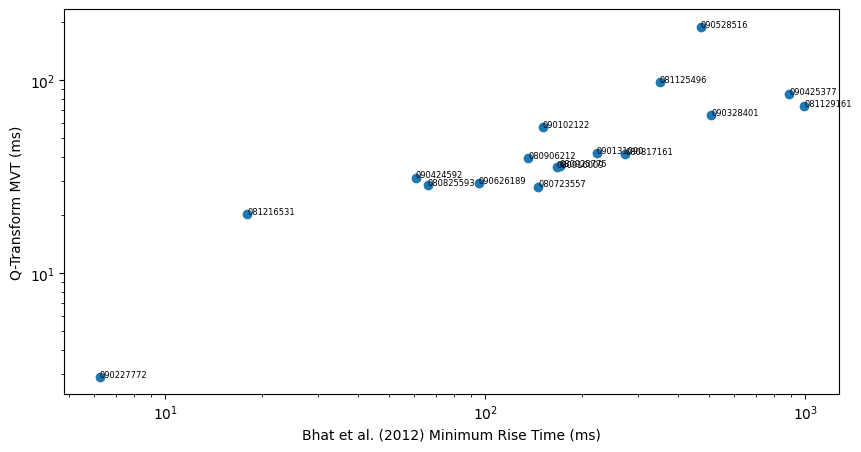

In [46]:
# Match with QTMVT results 
matched = []

for a in results:
    # Filter the dataframe to only rows where the GRB column matches one we have results for 
    match = bhat_min_rise[bhat_min_rise['GRB'] == a['GRB']]
    # If there is a match and we have a QTMVT for it, adds a dictionary with the GRB name, the QTMVT (in ms), andd the Bhat min rise time (in ms)
    if not match.empty and np.isfinite(a['QTMVT']):
        matched.append({'GRB': a['GRB'],'QTMVT_ms':a['QTMVT'],'bhat_min_rise_ms': match['bhat_min_rise_s'].values[0]*1000})

matched_DF = pd.DataFrame(matched)
print(f"Matched GRBs: {len(matched_DF)}") # Number of overlapping GRBs 
print(matched_DF) # Print the dictionary  

# Do a Spearman correlation test on the QTMVT versus the Bhat Minimum Rise Time 
rho_bhat, p_bhat = spearmanr(matched_DF['QTMVT_ms'], matched_DF['bhat_min_rise_ms'])
print(f"\n QTMVT vs Bhat et al. minimum rise time: rho = {rho_bhat:.3f}, p = {p_bhat:.8f}")

### Plotting ###
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(matched_df['bhat_min_rise_ms'], matched_df['QTMVT_ms'])
ax.set_yscale('log')
ax.set_xscale('log')
for index,row in matched_DF.iterrows(): # Label the plot points
    ax.annotate(row['GRB'][3:], (row['bhat_min_rise_ms'],row['QTMVT_ms']), fontsize=6)
ax.set_xlabel('Bhat et al. (2012) Minimum Rise Time (ms)')
ax.set_ylabel('Q-Transform MVT (ms)')